In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score


In [8]:
housing= fetch_california_housing()
data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

In [9]:
x= data[['AveRooms']].values
y= data['Price'].values

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [30]:
w= 0
b= 0
learning_rate= 0.02
epochs=1000
n=len(x_train_scaled)
cost_history=[]
for i in range(epochs):
    y_pred= w*x_train_scaled.flatten()+ b
    dw= (1/n)* np.sum((y_pred-y_train)*x_train_scaled.flatten())
    db= (1/n)* np.sum(y_pred-y_train)
    w=w-learning_rate*dw
    b=b-learning_rate* db
    if i%100==0:
        cost=(1/(2*n))* np.sum((y_pred - y_train)**2)
        print(f"epoch{i},cost=cost{cost:.4f}")
        cost_history.append(cost)
        y_pred_gd= w* x_test_scaled.flatten()+b

epoch0,cost=cost2.8149
epoch100,cost=cost0.6896
epoch200,cost=cost0.6523
epoch300,cost=cost0.6516
epoch400,cost=cost0.6516
epoch500,cost=cost0.6516
epoch600,cost=cost0.6516
epoch700,cost=cost0.6516
epoch800,cost=cost0.6516
epoch900,cost=cost0.6516


In [31]:
print("gradient descent")
print("----------------")
print("weight:",w)
print("bias:",b)
print("mse:",mean_squared_error(y_test,y_pred_gd))
print("r2 score:",r2_score(y_test,y_pred_gd))

gradient descent
----------------
weight: 0.18323881682652998
bias: 2.0719469338918577
mse: 1.2923314429870518
r2 score: 0.01379533836689295


In [32]:
x_train_ne=np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne=np.c_[np.ones((len(x_test),1)),x_test]
theta=np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne=x_test_ne @ theta



In [33]:
print("\nNormal Equation")
print("-----------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 score:",r2_score(y_test,y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 score: 0.013795337532284901


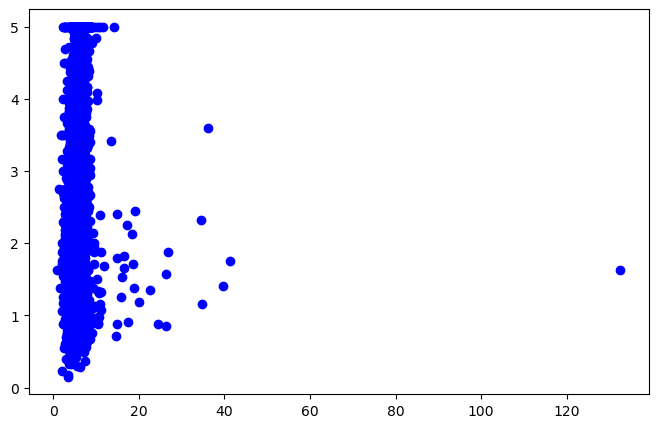

In [34]:
index=np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(x_test,y_test,color='blue',label='Actual Data')

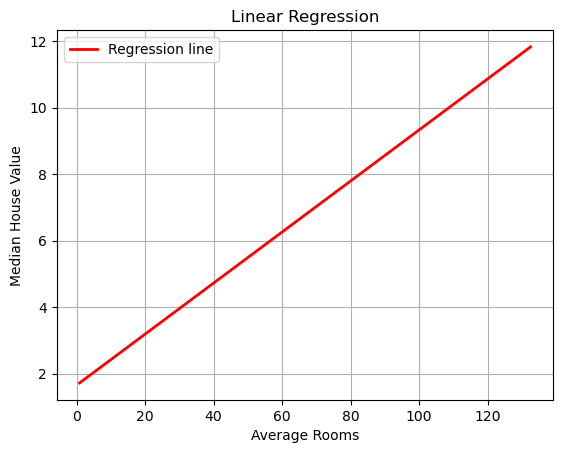

In [35]:
plt.plot(x_test.flatten()[index],y_pred_ne[index],color='red',linewidth=2,label='Regression line')
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient DEScent cost convergence curve')
plt.xlabel('iterations')
plt.ylabel('cost J(0)')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()